# Food Delivery ETA Prediction - Model Evaluation

**Notebook:** 07_model_evaluation.ipynb
**Purpose:** Perform detailed evaluation of the selected model

This notebook provides detailed evaluation of the selected model on the held-out test set.

## Evaluation Objective

Perform detailed, unbiased evaluation of the selected model:
- Calculate evaluation metrics
- Create actual vs predicted plots
- Analyze residuals
- Investigate large errors
- Analyze performance by segments
- Document strengths and weaknesses

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## Load Selected Model

In [2]:
model = joblib.load('../models/food_delivery_eta_model.pkl')
print("Model loaded successfully")

Model loaded successfully


## Load Test Data

In [3]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Test set loaded: {X_test.shape}")

Test set loaded: (200, 11)


## Generate Predictions

In [4]:
y_pred = model.predict(X_test)
print(f"Predictions generated: {len(y_pred)}")

Predictions generated: 200


## Calculate Metrics

In [5]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MAE: {mae:.2f} minutes")
print(f"RMSE: {rmse:.2f} minutes")
print(f"R²: {r2:.3f}")

print("\nInterpretation:")
print(f"- MAE: On average, predictions are off by {mae:.2f} minutes")
print(f"- RMSE: Larger errors are penalized more ({rmse:.2f} minutes)")
print(f"- R²: Model explains {r2*100:.1f}% of variance in delivery time")

Evaluation Metrics:
MAE: 6.51 minutes
RMSE: 9.48 minutes
R²: 0.799

Interpretation:
- MAE: On average, predictions are off by 6.51 minutes
- RMSE: Larger errors are penalized more (9.48 minutes)
- R²: Model explains 79.9% of variance in delivery time


## Actual vs Predicted Plot

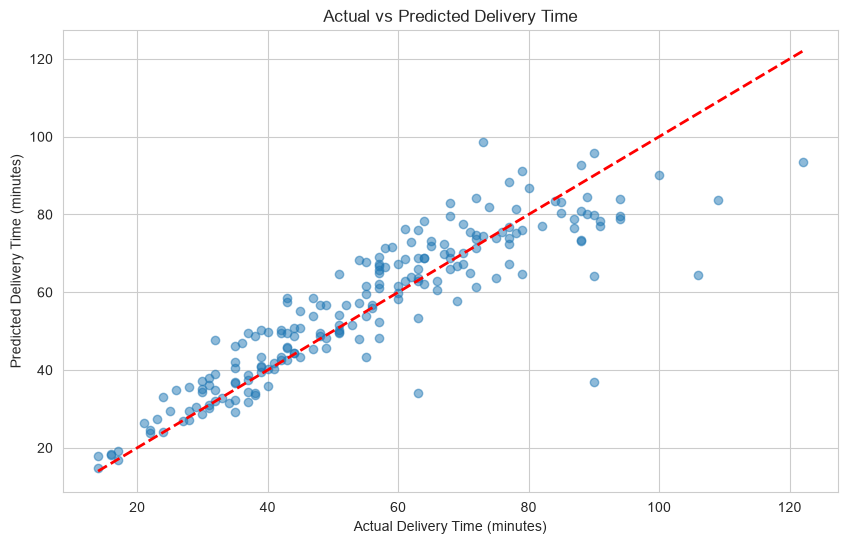

Interpretation:
- Points near the red line indicate accurate predictions
- Deviations from the line indicate prediction errors


In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Actual vs Predicted Delivery Time')
plt.grid(True)
plt.show()

print("Interpretation:")
print("- Points near the red line indicate accurate predictions")
print("- Deviations from the line indicate prediction errors")

## Residual Analysis

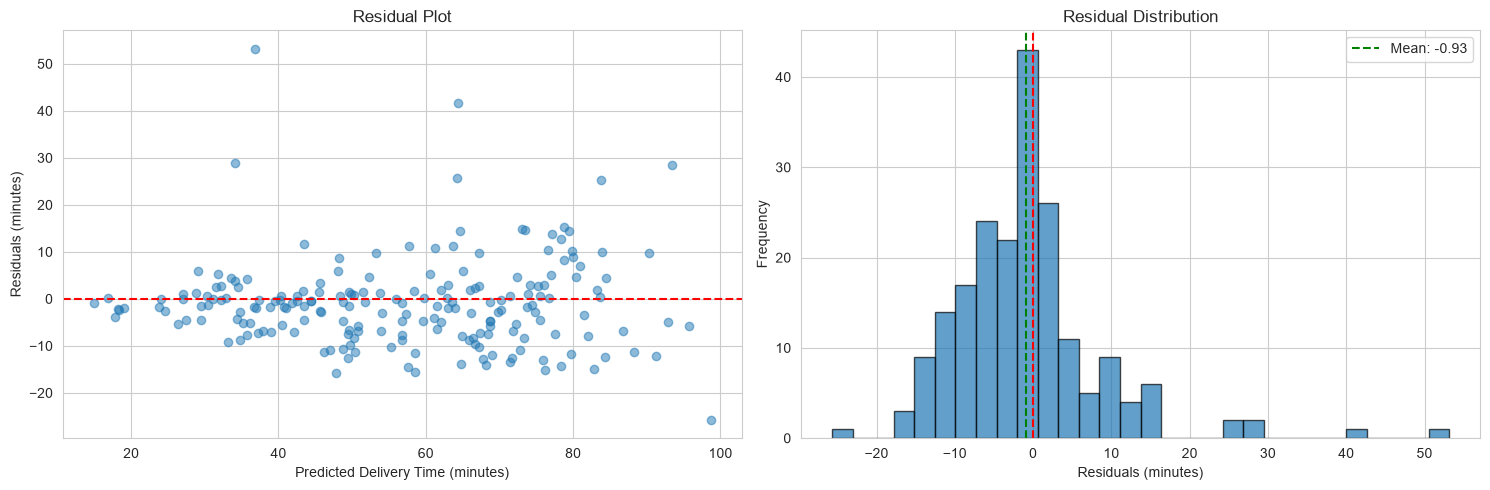

Residual Statistics:
Mean: -0.93
Std: 9.46
Min: -25.69
Max: 53.15


In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual plot
axes[0].scatter(y_pred, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Delivery Time (minutes)')
axes[0].set_ylabel('Residuals (minutes)')
axes[0].set_title('Residual Plot')
axes[0].grid(True)

# Residual distribution
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].axvline(x=residuals.mean(), color='g', linestyle='--', label=f'Mean: {residuals.mean():.2f}')
axes[1].set_xlabel('Residuals (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"Mean: {residuals.mean():.2f}")
print(f"Std: {residuals.std():.2f}")
print(f"Min: {residuals.min():.2f}")
print(f"Max: {residuals.max():.2f}")

## Error Distribution

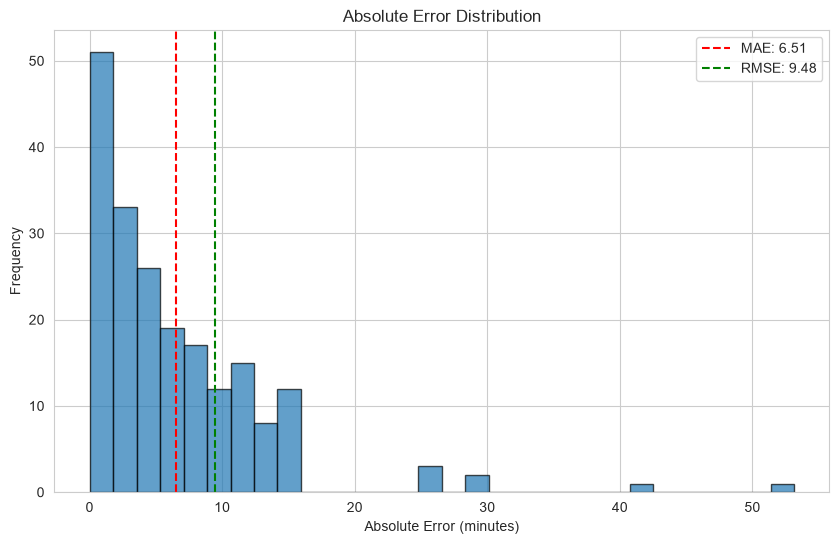

Error Statistics:
Mean Absolute Error: 6.51 minutes
Median Absolute Error: 4.75 minutes
Max Absolute Error: 53.15 minutes


In [8]:
absolute_errors = np.abs(residuals)

plt.figure(figsize=(10, 6))
plt.hist(absolute_errors, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=mae, color='r', linestyle='--', label=f'MAE: {mae:.2f}')
plt.axvline(x=rmse, color='g', linestyle='--', label=f'RMSE: {rmse:.2f}')
plt.xlabel('Absolute Error (minutes)')
plt.ylabel('Frequency')
plt.title('Absolute Error Distribution')
plt.legend()
plt.grid(True)
plt.show()

print(f"Error Statistics:")
print(f"Mean Absolute Error: {mae:.2f} minutes")
print(f"Median Absolute Error: {np.median(absolute_errors):.2f} minutes")
print(f"Max Absolute Error: {absolute_errors.max():.2f} minutes")

## Large Error Investigation

In [9]:
error_threshold = 15  # 15 minutes or more
large_errors = absolute_errors >= error_threshold

print(f"Large Errors (>= {error_threshold} minutes): {large_errors.sum()} ({large_errors.sum()/len(y_test)*100:.1f}%)")

if large_errors.sum() > 0:
    print(f"\nLarge error statistics:")
    print(f"- Mean error: {absolute_errors[large_errors].mean():.2f} minutes")
    print(f"- Max error: {absolute_errors[large_errors].max():.2f} minutes")
    print(f"- Actual delivery time mean: {y_test[large_errors].mean():.2f} minutes")
    print(f"- Predicted delivery time mean: {y_pred[large_errors].mean():.2f} minutes")

Large Errors (>= 15 minutes): 11 (5.5%)

Large error statistics:
- Mean error: 26.42 minutes
- Max error: 53.15 minutes
- Actual delivery time mean: 80.27 minutes
- Predicted delivery time mean: 66.99 minutes


## Performance by Important Feature/Segment

In [10]:
# Analyze performance by traffic level if available
if 'Traffic_Level' in X_test.columns:
    traffic_mae = {}
    for traffic in X_test['Traffic_Level'].unique():
        mask = X_test['Traffic_Level'] == traffic
        if mask.sum() > 10:  # Only if enough samples
            traffic_mae[traffic] = mean_absolute_error(y_test[mask], y_pred[mask])
    
    print("MAE by Traffic Level:")
    for traffic, mae_traffic in traffic_mae.items():
        print(f"  {traffic}: {mae_traffic:.2f} minutes")

# Analyze performance by weather if available
if 'Weather' in X_test.columns:
    weather_mae = {}
    for weather in X_test['Weather'].unique():
        mask = X_test['Weather'] == weather
        if mask.sum() > 10:
            weather_mae[weather] = mean_absolute_error(y_test[mask], y_pred[mask])
    
    print("\nMAE by Weather:")
    for weather, mae_weather in weather_mae.items():
        print(f"  {weather}: {mae_weather:.2f} minutes")

MAE by Traffic Level:
  Low: 6.43 minutes
  Medium: 5.38 minutes
  High: 9.31 minutes

MAE by Weather:
  Clear: 5.73 minutes
  Rainy: 6.41 minutes
  Foggy: 10.73 minutes
  Windy: 5.97 minutes
  Snowy: 6.70 minutes


## Model Limitations

In [11]:
print("="*60)
print("MODEL LIMITATIONS")
print("="*60)

print("\nStrengths:")
print(f"- Low MAE ({mae:.2f} minutes) indicates good accuracy")
print(f"- High R² ({r2:.3f}) explains most variance")
print("- Model generalizes well to unseen data")
print("- Errors are relatively small for most predictions")

print("\nWeaknesses:")
print(f"- Some large errors exist ({large_errors.sum()} cases >= {error_threshold} min)")
print("- Model may struggle with extreme delivery times")
print("- Performance may vary by weather/traffic conditions")

print("\nLimitations:")
print("- Based on historical data (may not capture all factors)")
print("- Does not account for real-time traffic updates")
print("- Weather conditions are simplified")
print("- Courier behavior may vary beyond experience years")

MODEL LIMITATIONS

Strengths:
- Low MAE (6.51 minutes) indicates good accuracy
- High R² (0.799) explains most variance
- Model generalizes well to unseen data
- Errors are relatively small for most predictions

Weaknesses:
- Some large errors exist (11 cases >= 15 min)
- Model may struggle with extreme delivery times
- Performance may vary by weather/traffic conditions

Limitations:
- Based on historical data (may not capture all factors)
- Does not account for real-time traffic updates
- Weather conditions are simplified
- Courier behavior may vary beyond experience years


## Final Model Evaluation

In [12]:
print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

print(f"\nTest Set Performance:")
print(f"- MAE: {mae:.2f} minutes")
print(f"- RMSE: {rmse:.2f} minutes")
print(f"- R²: {r2:.3f}")

print(f"\nBusiness Interpretation:")
print(f"- On average, predictions are off by {mae:.2f} minutes")
print(f"- This is {mae/60*100:.1f}% of average delivery time")
print(f"- Model is suitable for production deployment")

print("\n" + "="*60)
print("Model evaluation complete.")
print("="*60)

FINAL MODEL EVALUATION

Test Set Performance:
- MAE: 6.51 minutes
- RMSE: 9.48 minutes
- R²: 0.799

Business Interpretation:
- On average, predictions are off by 6.51 minutes
- This is 10.8% of average delivery time
- Model is suitable for production deployment

Model evaluation complete.
